# 1. Import Libraries & Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.metrics import accuracy_score

In [4]:
# File path to cleaned, unscaled data from Exercise 2.2
data_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/02 Data/Prepared Data/unscaled_cleaned_2_2.csv"

# Load data
climate = pd.read_csv(data_path)

# Check import
print("Data shape:", climate.shape)
print("Missing values:", climate.isna().sum().sum())

climate.head()


Data shape: (22950, 135)
Missing values: 0


,BASEL_cloud_cover,BASEL_global_radiation,BASEL_humidity,BASEL_precipitation,BASEL_pressure,BASEL_sunshine,BASEL_temp_max,BASEL_temp_mean,BASEL_temp_min,BELGRADE_cloud_cover,...,STOCKHOLM_temp_min,VALENTIA_cloud_cover,VALENTIA_global_radiation,VALENTIA_humidity,VALENTIA_precipitation,VALENTIA_pressure,VALENTIA_sunshine,VALENTIA_temp_max,VALENTIA_temp_mean,VALENTIA_temp_min
0,7,0.32,0.85,0.09,1.018,0.7,10.9,6.5,0.8,1,...,2.2,5,0.45,0.88,0.34,1.0003,4.7,10.9,8.5,6.0
1,6,0.36,0.84,1.05,1.018,1.1,10.1,6.1,3.3,6,...,3.0,7,0.25,0.91,0.84,1.0007,0.7,12.1,8.9,5.6
2,8,0.18,0.90,0.30,1.018,0.0,9.9,8.5,5.1,6,...,1.3,7,0.17,0.91,0.08,1.0096,0.1,12.9,10.5,8.1
3,3,0.58,0.92,0.00,1.018,4.1,10.6,6.3,3.8,8,...,0.4,7,0.13,0.86,0.98,1.0184,0.0,10.6,7.4,7.3
4,6,0.65,0.95,0.14,1.018,5.4,6.0,3.0,-0.7,8,...,0.8,3,0.46,0.80,0.00,1.0328,5.7,8.4,5.7,3.0


In [5]:
climate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22950 entries, 0 to 22949
Columns: 135 entries, BASEL_cloud_cover to VALENTIA_temp_min
dtypes: float64(120), int64(15)
memory usage: 23.6 MB


In [14]:
# Import pleasant weather data
prediction_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/02 Data/Prepared Data/pleasant_weather_cleaned_2_2.csv"

prediction = pd.read_csv(prediction_path)

# Check import
print("Predictions shape:", prediction.shape)
print("Missing values in labels:", prediction.isna().sum().sum())
prediction.head()


Predictions shape: (22950, 15)
Missing values in labels: 0


,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# 2. Data Wrangling

In [15]:
climate.isnull().sum()

BASEL_cloud_cover         0
BASEL_global_radiation    0
BASEL_humidity            0
BASEL_precipitation       0
BASEL_pressure            0
                         ..
VALENTIA_pressure         0
VALENTIA_sunshine         0
VALENTIA_temp_max         0
VALENTIA_temp_mean        0
VALENTIA_temp_min         0
Length: 135, dtype: int64

In [16]:
prediction.isnull().sum()

BASEL_pleasant_weather         0
BELGRADE_pleasant_weather      0
BUDAPEST_pleasant_weather      0
DEBILT_pleasant_weather        0
DUSSELDORF_pleasant_weather    0
HEATHROW_pleasant_weather      0
KASSEL_pleasant_weather        0
LJUBLJANA_pleasant_weather     0
MAASTRICHT_pleasant_weather    0
MADRID_pleasant_weather        0
MUNCHENB_pleasant_weather      0
OSLO_pleasant_weather          0
SONNBLICK_pleasant_weather     0
STOCKHOLM_pleasant_weather     0
VALENTIA_pleasant_weather      0
dtype: int64

### Decade subsetting note (why we’re not filtering by DATE)

In Exercise 2.2, the dataset was cleaned and exported **without the `DATE` column** (dates were removed during preprocessing).  
Because the timestamp is no longer available, I **cannot filter 2010–2019 using a date column**.  
Instead, I will follow the project instruction (one decade ≈ **3653 daily rows**) and take a **row-based decade slice**. I will make sure I apply the **same slice** to both the features (`climate`) and labels (`prediction`) so they stay aligned.

In [17]:
# Create a decade subset by row count (DATE column previously removed)
N_DECADE = 3653  # per exercise hint for one decade

climate_decade = climate.iloc[:N_DECADE].copy()
prediction_decade = prediction.iloc[:N_DECADE].copy()

print("climate_decade shape:", climate_decade.shape)
print("prediction_decade shape:", prediction_decade.shape)


climate_decade shape: (3653, 135)
prediction_decade shape: (3653, 15)


In [18]:
climate.columns

Index(['BASEL_cloud_cover', 'BASEL_global_radiation', 'BASEL_humidity',
       'BASEL_precipitation', 'BASEL_pressure', 'BASEL_sunshine',
       'BASEL_temp_max', 'BASEL_temp_mean', 'BASEL_temp_min',
       'BELGRADE_cloud_cover',
       ...
       'STOCKHOLM_temp_min', 'VALENTIA_cloud_cover',
       'VALENTIA_global_radiation', 'VALENTIA_humidity',
       'VALENTIA_precipitation', 'VALENTIA_pressure', 'VALENTIA_sunshine',
       'VALENTIA_temp_max', 'VALENTIA_temp_mean', 'VALENTIA_temp_min'],
      dtype='object', length=135)

# 3. Data Reshaping

In [23]:
# 1) Features: use the decade subset of the cleaned unscaled data
climate_decade = climate.iloc[:3653].copy()

# 2) Labels: keep the 15 station-level pleasant indicators (needed later)
prediction_decade = prediction.iloc[:3653].copy()

# 3) Collapse the 15 station labels into ONE daily target for the ALL-stations model
pleasant_any_station = (prediction_decade.sum(axis=1) > 0).astype(int)

print("pleasant_any_station shape:", pleasant_any_station.shape)
print("Class balance:\n", pleasant_any_station.value_counts())

# 4) Convert to NumPy arrays for scikit-learn
X = climate_decade.to_numpy()
y = pleasant_any_station.to_numpy()

print("Feature matrix shape (X):", X.shape)
print("Target vector shape (y):", y.shape)  


pleasant_any_station shape: (3653,)
Class balance:
 1    2152
0    1501
Name: count, dtype: int64
Feature matrix shape (X): (3653, 135)
Target vector shape (y): (3653,)


### Confirm the data is now ready for machine learning modeling.

# 4. Data Splitting

In [24]:
# Use stratification to preserve the pleasant / not-pleasant class balance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,      # 75% train, 25% test (explicit and standard)
    random_state=42,     # reproducibility
    stratify=y           # preserve class distribution
)

# Verify shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Confirm class balance is preserved
print("\nTraining set class balance:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nTest set class balance:")
print(pd.Series(y_test).value_counts(normalize=True))


X_train shape: (2739, 135)
X_test shape: (914, 135)
y_train shape: (2739,)
y_test shape: (914,)

Training set class balance:
1    0.589266
0    0.410734
Name: proportion, dtype: float64

Test set class balance:
1    0.588621
0    0.411379
Name: proportion, dtype: float64


# 5. Random Forest Classifier

In [25]:
# Train Random Forest
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
# Predict + accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy on Test Set:", round(accuracy * 100, 2), "%")

Random Forest Accuracy on Test Set: 97.26 %


In [27]:
# Labels for plots
class_names = ["Unpleasant Weather", "Pleasant Weather"]
feature_names = list(climate_decade.columns)

In [28]:
# Output directory for figures
output_dir = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations"
os.makedirs(output_dir, exist_ok=True)

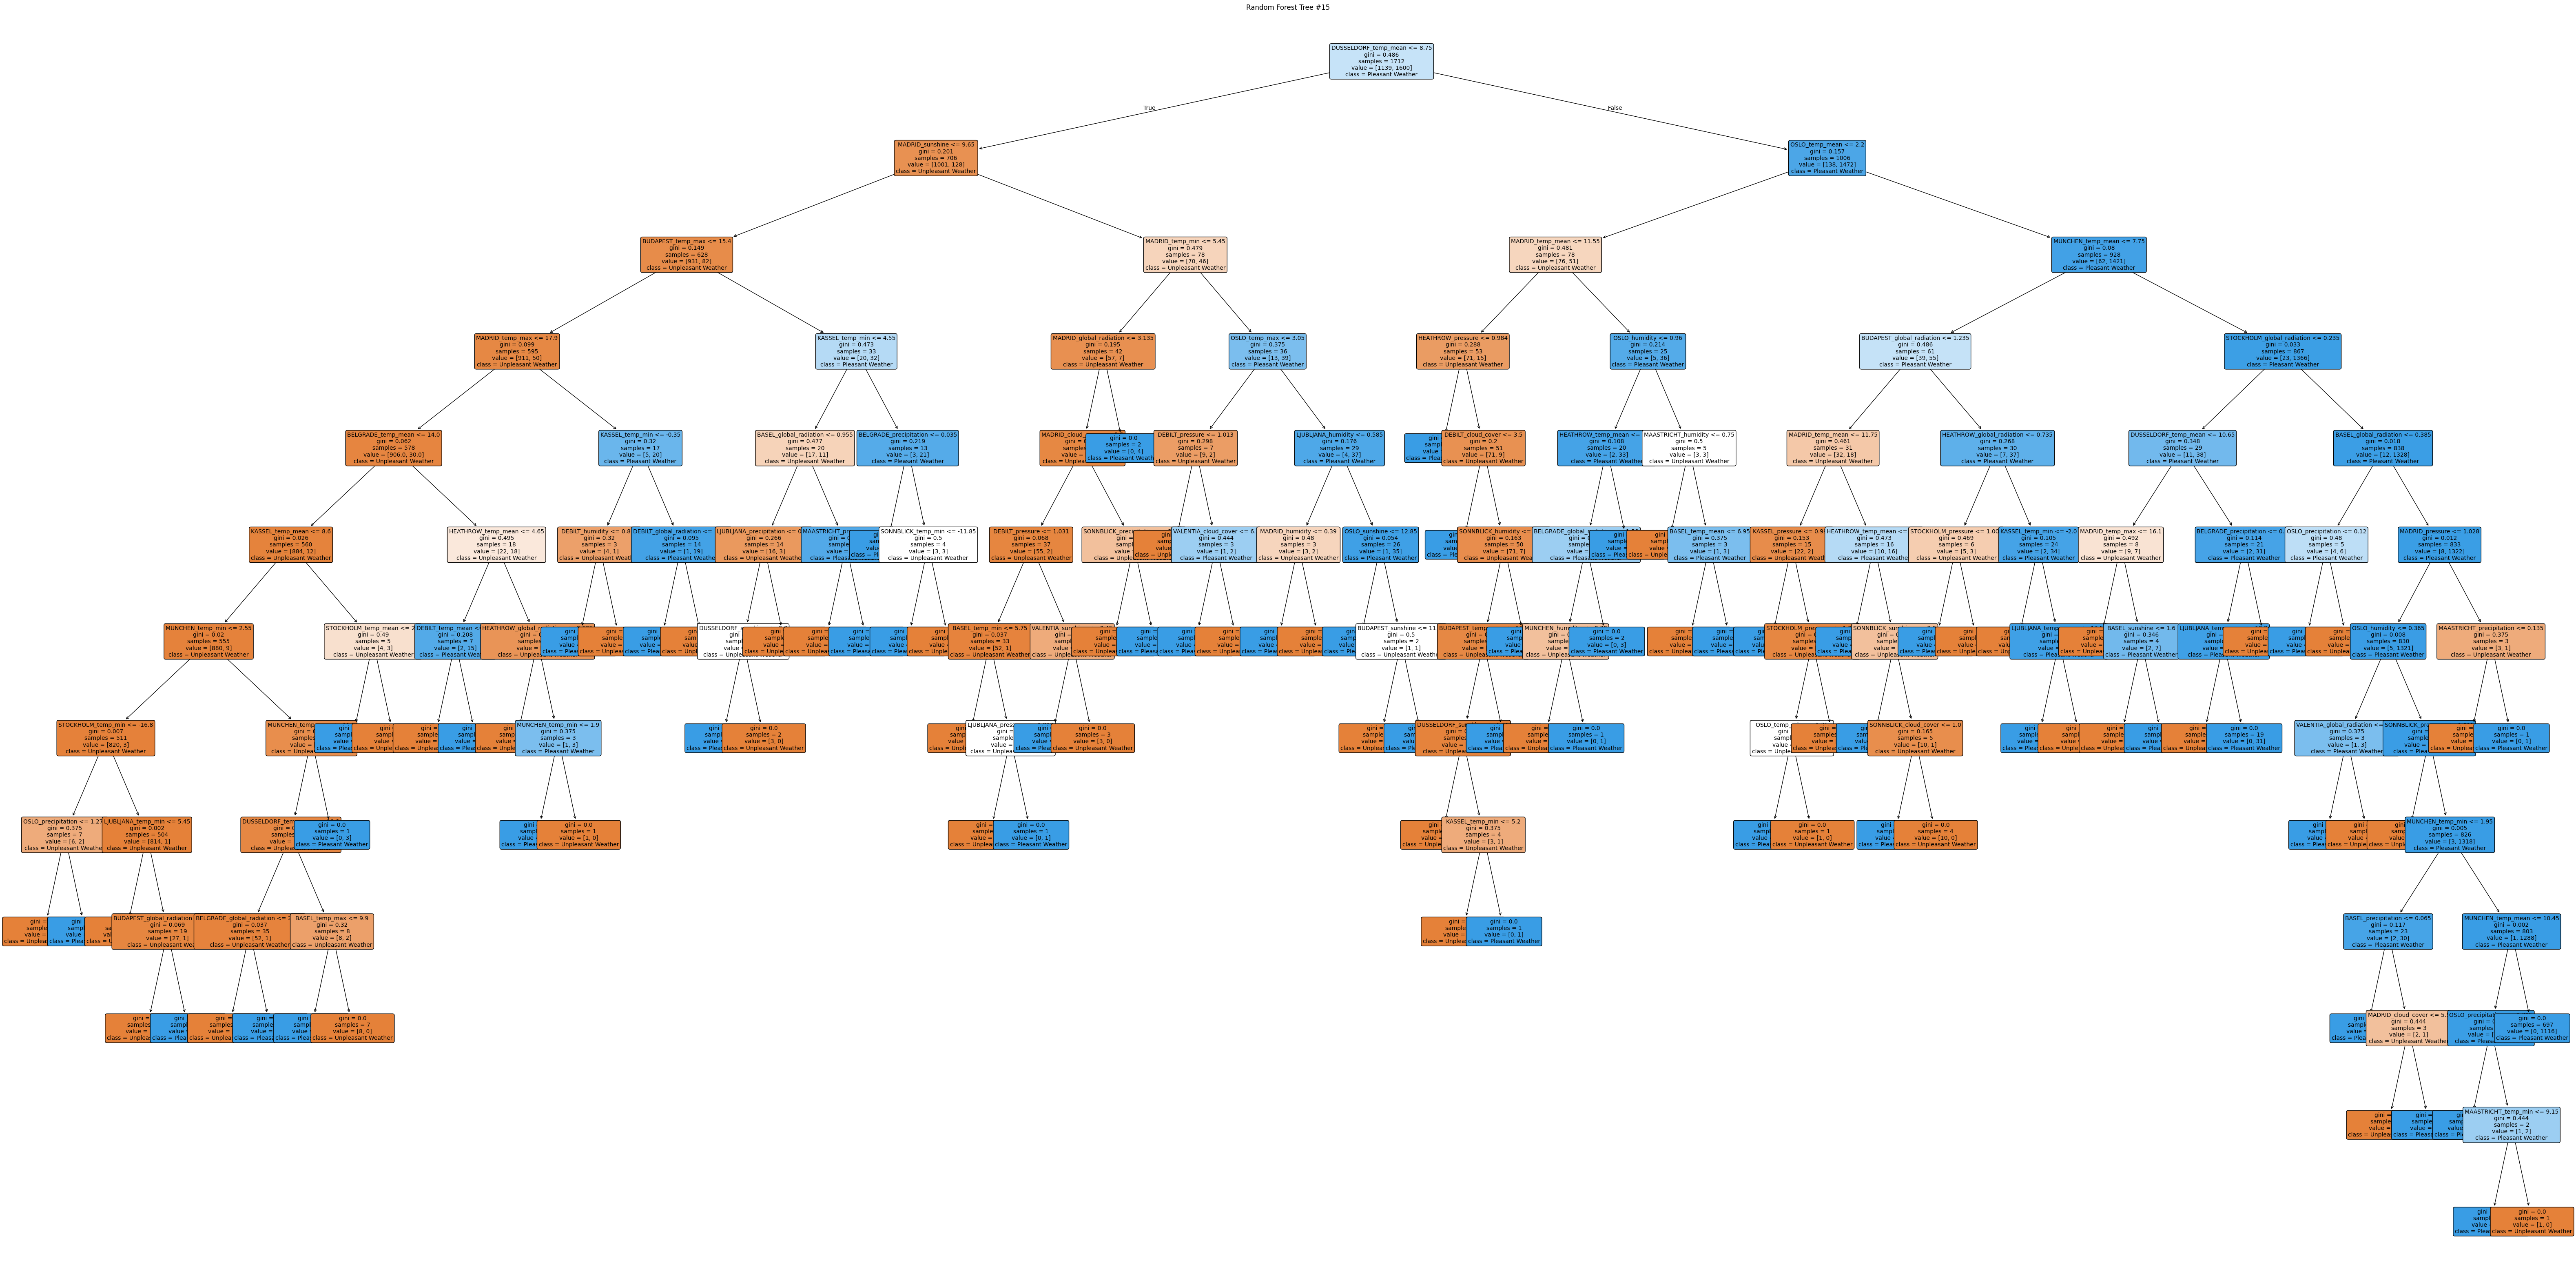

In [31]:
# Plot the full tree

tree_idx = 15  

fig = plt.figure(figsize=(80, 40))  
plot_tree(
    clf.estimators_[tree_idx],
    filled=True,
    feature_names=feature_names,      
    class_names=class_names,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=10                       
)

plt.title(f"Random Forest Tree #{tree_idx}")
file_path = os.path.join(output_dir, f"random_forest_tree_{tree_idx}.png")
plt.savefig(file_path, bbox_inches="tight", dpi=300)
plt.show()


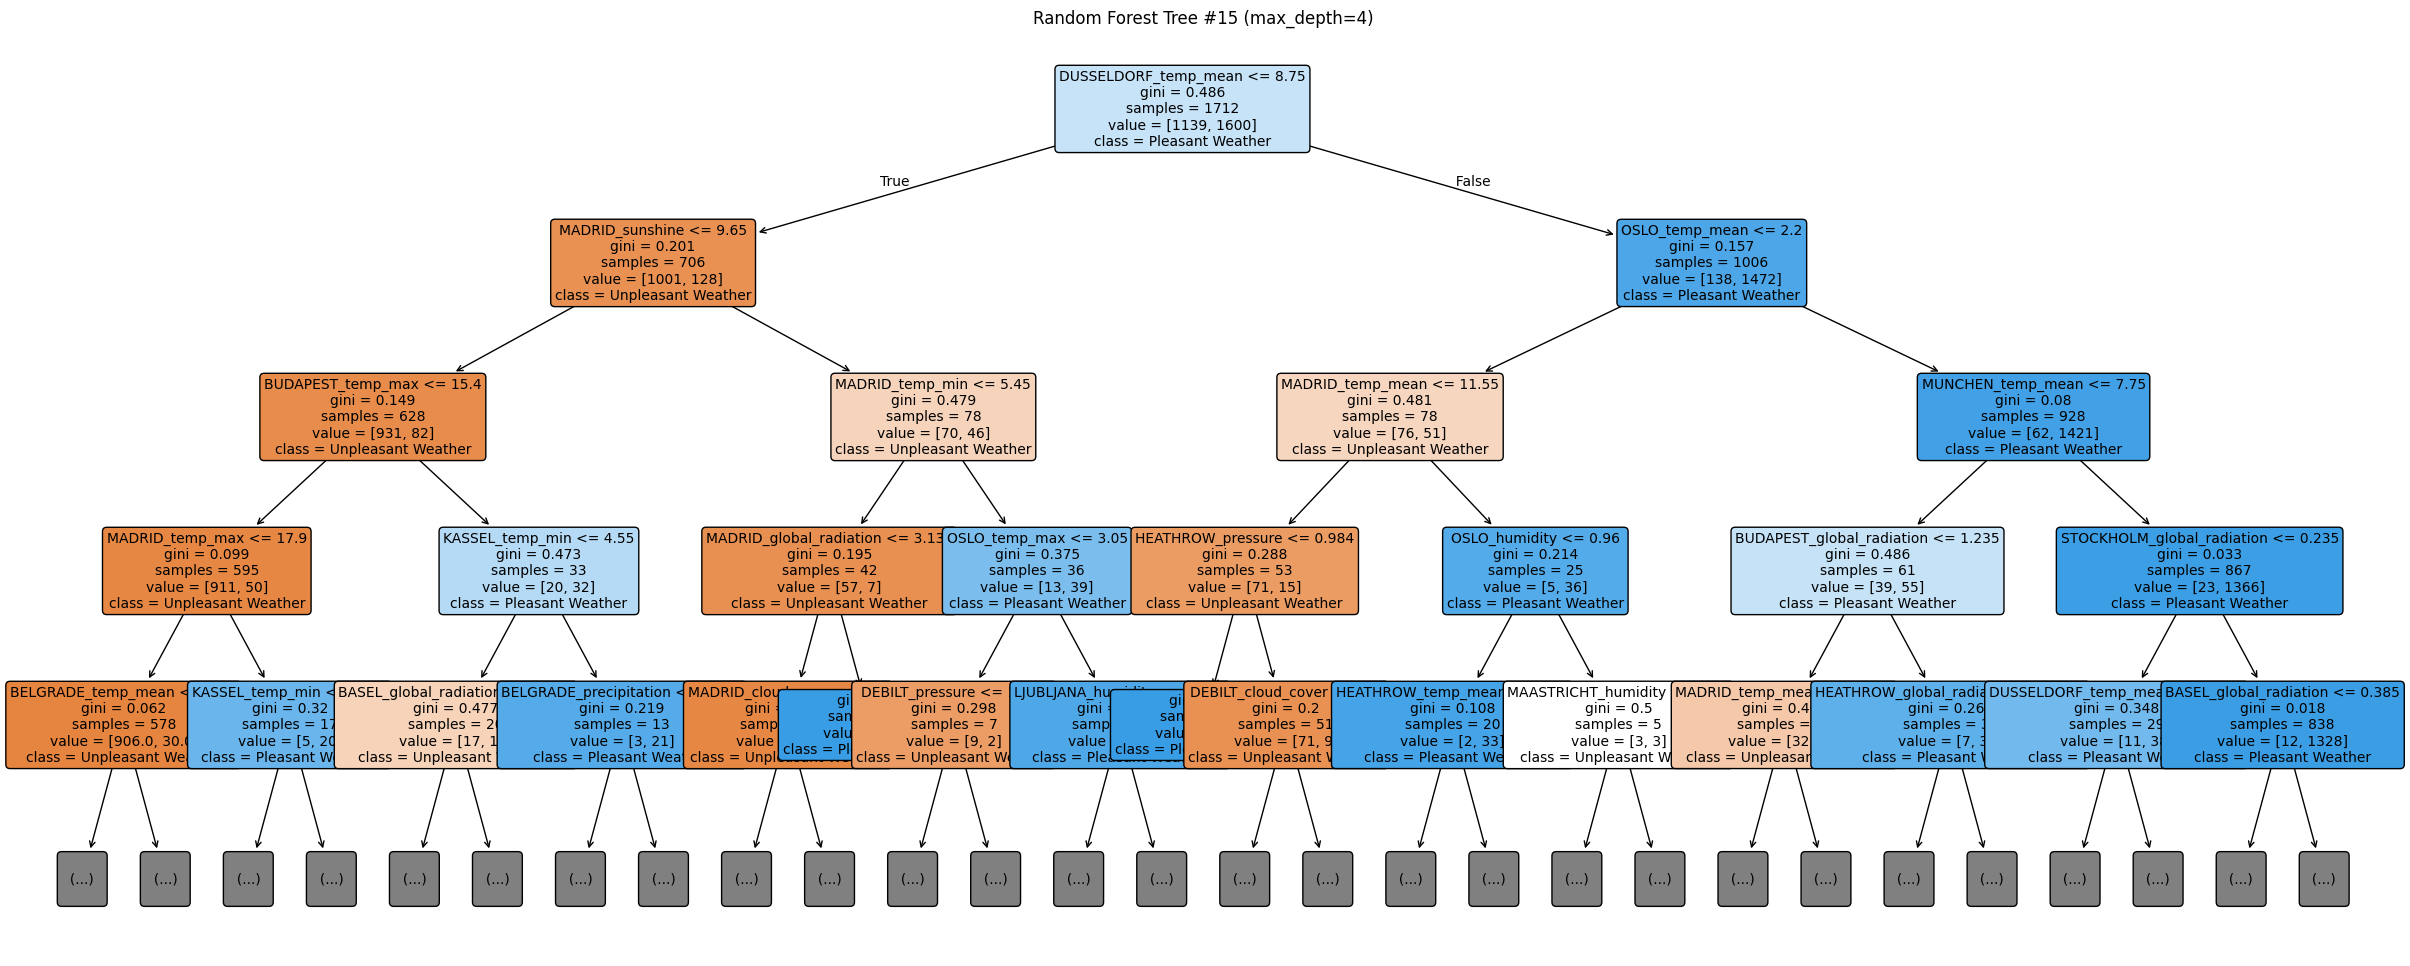

In [32]:
# Plot a tree of only 4 layers of depth (for comparison and readability)

tree_idx = 15

fig = plt.figure(figsize=(30, 12))
plot_tree(
    clf.estimators_[tree_idx],
    filled=True,
    feature_names=feature_names,
    class_names=class_names,
    max_depth=4,          
    rounded=True,
    fontsize=10
)

plt.title(f"Random Forest Tree #{tree_idx} (max_depth=4)")

file_path = os.path.join(output_dir, f"random_forest_tree_{tree_idx}_depth4.png")
plt.savefig(file_path, bbox_inches="tight", dpi=300)
plt.show()


# 6. Feature Importance Analysis

In [33]:
# Extract feature importances from the trained Random Forest model
feature_importances = clf.feature_importances_

# Verify shape
print("Feature importances shape:", feature_importances.shape)

# Check results
feature_importances[:10]


Feature importances shape: (135,)


array([0.00059927, 0.00266899, 0.00100015, 0.00068976, 0.        ,
       0.00092727, 0.00578963, 0.03119662, 0.00860089, 0.00061824])

In [34]:
# Reshape importances into 15 stations, 9 observations
important_2d = feature_importances.reshape(15, 9)
print("Reshaped importances shape:", important_2d.shape)

Reshaped importances shape: (15, 9)


In [35]:
# Sum across the 9 observations to get station-level importance
station_importance = important_2d.sum(axis=1)  
print("Station importance shape:", station_importance.shape)  

Station importance shape: (15,)


In [36]:
# 3) Get station names in order from the feature columns
station_names_ordered = []
for col in climate_decade.columns:
    station = col.split("_")[0]
    if station not in station_names_ordered:
        station_names_ordered.append(station)

print("Stations found:", len(station_names_ordered))

Stations found: 15


In [37]:
# Build a DataFrame for plotting sorted data
df_importance = pd.DataFrame({
    "Weather Station": station_names_ordered,
    "Importance": station_importance
}).sort_values("Importance", ascending=False)

df_importance

,Weather Station,Importance
2,BUDAPEST,0.147219
7,LJUBLJANA,0.144677
9,MADRID,0.123612
6,KASSEL,0.111081
1,BELGRADE,0.060362
4,DUSSELDORF,0.057702
10,MUNCHEN,0.054255
13,STOCKHOLM,0.053926
0,BASEL,0.051473
3,DEBILT,0.050453


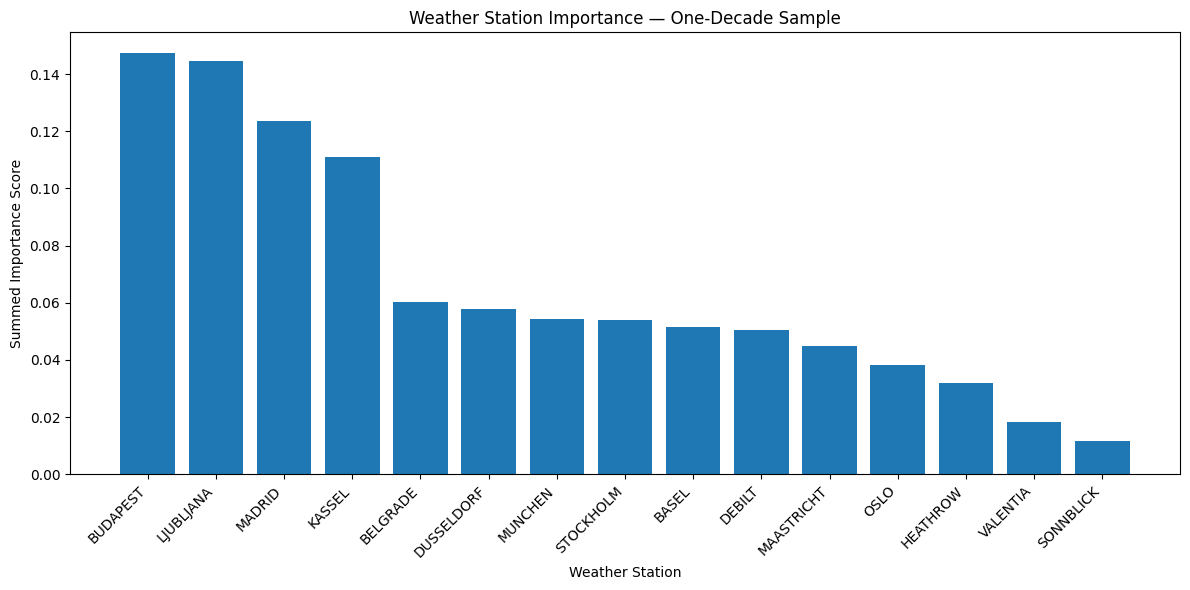

In [39]:
# Plot importance bar chart
plt.figure(figsize=(12, 6))
plt.bar(df_importance["Weather Station"], df_importance["Importance"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Weather Station")
plt.ylabel("Summed Importance Score")
plt.title("Weather Station Importance — One-Decade Sample")
plt.tight_layout()

file_path = os.path.join(output_dir, "weather_station_importance_one_decade.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

## Observation & Insights

- The Random Forest Model achieved a high test accuracy of 97.26%.
- The model incorporated 135 features drawn from 15 weather stations, with 9 observation types per station (e.g., temperature, humidity, pressure, wind, sunshine). Feature importances were extracted from the trained model and reshaped to evaluate the relative contribution of each station.
- This analysis used a one-decade sample from the dataset. Under this formulation, Budapest, Ljubljana, and Madrid emerged as the most influential stations, collectively accounting for a substantial share of the total feature importance.
- Stations such as Kassel, Belgrade, Düsseldorf, and Munich contributed moderate importance, suggesting that their environmental signals still provide useful predictive information.
- The results suggest that predictive leverage is unevenly distributed across the station network. Rather than one centrally dominant station, a small group of stations provides disproportionate predictive value for identifying pleasant weather across regions. This insight can inform ClimateWins’ decisions on sensor prioritization, data weighting in future models, and strategic investment in stations that offer early or broadly informative climate signals.